In [119]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [120]:
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

In [121]:
df.shape

(42000, 785)

In [122]:
import matplotlib.pyplot as plt

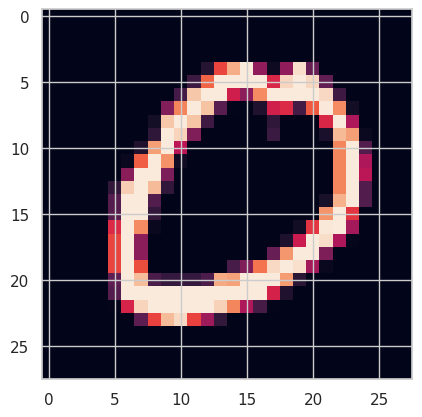

In [123]:
plt.imshow(df.iloc[13051,1:].values.reshape(28,28))

In [124]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train, y_test =train_test_split(df.iloc[:,1:] ,df.iloc[:,1], random_state=12 , test_size=0.3)

In [125]:
from sklearn.neighbors import KNeighborsClassifier

In [126]:
knn = KNeighborsClassifier()

In [127]:
knn.fit(x_train , y_train)

KNeighborsClassifier()

In [128]:
knn.predict(x_test)

array([0, 0, 0, ..., 0, 0, 0])

In [129]:
from sklearn.metrics import accuracy_score
accuracy_score(knn.predict(x_test) , y_test)

1.0

In [130]:
from sklearn.preprocessing import StandardScaler

In [131]:
sc =StandardScaler()
x_train  =sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [132]:
from sklearn.decomposition import PCA

In [133]:
pca=PCA(n_components = 100)

In [134]:
x_train1 = pca.fit_transform(x_train)
x_test1 = pca.transform(x_test)

In [135]:
x_train1.shape

(29400, 100)

In [136]:
knn = KNeighborsClassifier()
knn.fit(x_train1 , y_train)
accuracy_score(knn.predict(x_test1) , y_test)

1.0

In [137]:
pca= PCA(n_components=2)
x_train2 =pca.fit_transform(x_train ,y_train)
x_test2 =pca.transform(x_test)


In [138]:
import seaborn as sns

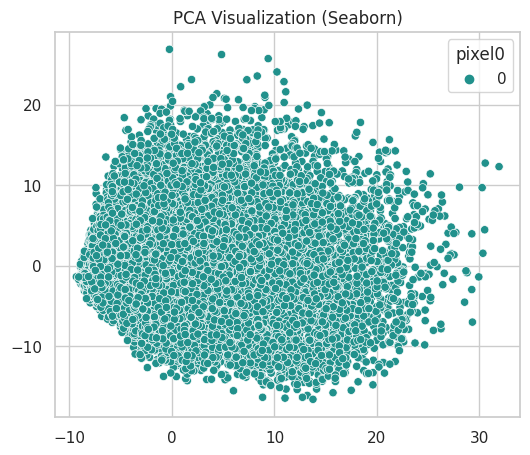

In [139]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=x_train2[:, 0], y=x_train2[:, 1], hue=y_train, palette="viridis")
plt.title("PCA Visualization (Seaborn)")
plt.show()


In [140]:
import plotly.express as px
import plotly.io as pio

# Set renderer (adjust if needed: "notebook", "colab", "browser", "vscode")
pio.renderers.default = "notebook"

fig = px.scatter(
    x=x_train2[:, 0],
    y=x_train2[:, 1],
    color=y_train.astype(str),   # Convert labels to strings for coloring
    title="PCA Visualization (Plotly)",
    labels={"x": "PC1", "y": "PC2"},
    color_discrete_sequence=px.colors.qualitative.Set1  # Pick a nice palette
)
fig.show()


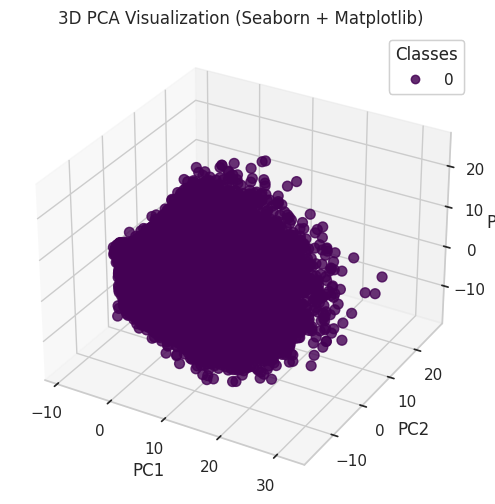

In [141]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D projection

# ---------------- PCA with 3 components ----------------
pca = PCA(n_components=3)
x_train3 = pca.fit_transform(x_train)   # Only X
x_test3 = pca.transform(x_test)

# ---------------- 3D Scatter with Seaborn Style ----------------
sns.set(style="whitegrid")  # Seaborn theme

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    x_train3[:, 0], 
    x_train3[:, 1], 
    x_train3[:, 2], 
    c=y_train, 
    cmap="viridis",   # color map for numbers
    s=50, 
    alpha=0.8
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D PCA Visualization (Seaborn + Matplotlib)")

# Add legend for classes
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

plt.show()


In [142]:
pca.explained_variance_  # egien val
pca.components_ #eigen vec

array([[-2.11296413e-18,  8.20145701e-19,  3.02803788e-20, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-1.59434923e-17, -3.14708064e-18,  6.33945103e-19, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-5.71503430e-17,  4.46496598e-17, -1.34320454e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

# FINDING OPTIMAL PCA NO OF COMPONENTS

In [143]:
# EACH EIGEN VALUE TELL HOW HOW VAR OF DATA  IT EXPLAINS
# TOTAL NO OF PCA = K
# SUCH THAT K NO OF COMPONENTS HAS VAR >=90
pc1=PCA(n_components=None)
x1=pc1.fit_transform(x_train)



In [145]:
var = pc1.explained_variance_ratio_

In [149]:
var = np.cumsum(var)*100


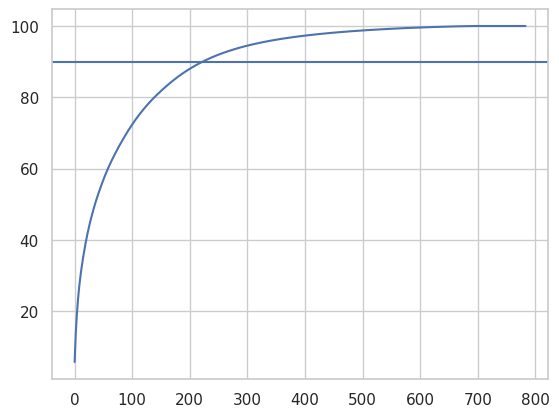

In [154]:
plt.plot(var)
plt.axhline(90)

In [ ]:
# when not use

# when data is in speical or specifc pattern
# data is spherical orirented